# Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning, ValueWarning

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
warnings.simplefilter('ignore', ConvergenceWarning)
warnings.simplefilter('ignore', ValueWarning)
warnings.simplefilter('ignore', FutureWarning)

# Data

In [25]:
df_ts = pd.read_parquet('./data/pp-complete.parquet')

df_ts['year'] = df_ts['date'].dt.year
df_ts

,price,date,postcode,type,old_new,duration,PAON SAON,street,locality,town_city,district,county,ppd_type,year
0,166500,1995-11-22,CM23 4PA,D,Y,F,19,MAYFLOWER GARDENS,BISHOP'S STORTFORD,BISHOP'S STORTFORD,EAST HERTFORDSHIRE,HERTFORDSHIRE,A,1995
1,59000,1995-09-27,L12 0AY,D,N,L,7,TRENT CLOSE,LIVERPOOL,LIVERPOOL,LIVERPOOL,MERSEYSIDE,A,1995
2,118000,1995-12-15,SL3 8XX,D,N,F,24,SOUTHWOLD SPUR,SLOUGH,SLOUGH,SLOUGH,SLOUGH,A,1995
3,48500,1995-01-27,CV12 8TF,S,N,F,5,CHELTENHAM CLOSE,BEDWORTH,BEDWORTH,NUNEATON AND BEDWORTH,WARWICKSHIRE,A,1995
4,27500,1995-04-20,SY11 1HP,S,N,F,105,BEATRICE STREET,OSWESTRY,OSWESTRY,OSWESTRY,SHROPSHIRE,A,1995
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30124348,177000,2025-01-24,NG2 3LH,T,N,F,7,ST SAVIOURS GARDENS,THE MEADOWS,NOTTINGHAM,CITY OF NOTTINGHAM,CITY OF NOTTINGHAM,A,2025
30124349,335000,2025-01-10,LE12 6NX,S,N,F,23,BLEY AVENUE,EAST LEAKE,LOUGHBOROUGH,RUSHCLIFFE,NOTTINGHAMSHIRE,A,2025
30124350,180000,2025-01-24,NG17 7JW,S,N,F,44,DAVID STREET,KIRKBY IN ASHFIELD,NOTTINGHAM,ASHFIELD,NOTTINGHAMSHIRE,A,2025
30124351,185000,2025-01-21,NG18 2RN,D,N,F,42,PARK VIEW WAY,,MANSFIELD,MANSFIELD,NOTTINGHAMSHIRE,A,2025


# Functions

In [26]:
def get_stationarity(timeseries):
    """Проверяет стационарность ряда и возвращает порядок дифференцирования d."""
    d = 0
    # Копируем, чтобы не изменять исходный ряд при дифференцировании
    current_series = timeseries.copy()
    
    # Проверяем исходный ряд
    result_adf = adfuller(current_series.dropna())
    print(f'ADF Statistic (d={d}): {result_adf[0]}')
    print(f'p-value (d={d}): {result_adf[1]}')
    
    # Дифференцируем, пока ряд не станет стационарным (или максимум 2 раза)
    while result_adf[1] > 0.05 and d < 2:
        d += 1
        current_series = current_series.diff().dropna()
        if current_series.empty: # Если после дифференцирования ничего не осталось
            print(f"Ряд стал пустым после {d} дифференцирования(ий).")
            return timeseries, d-1 # Возвращаем предыдущий d, если возможно, или 0
        result_adf = adfuller(current_series)
        print(f'\nADF Statistic (d={d}): {result_adf[0]}')
        print(f'p-value (d={d}): {result_adf[1]}')
        
    if result_adf[1] <= 0.05:
        print(f"\nРяд стационарен после {d} дифференцирования(ий).")
    else:
        print(f"\nРяд НЕ стационарен даже после {d} дифференцирования(ий). Используем d={d}.")
        
    return d

In [27]:
def plot_arima_forecast_statsmodels(series_actual_price_input, category_name, df_results, n_periods=3, title_prefix="", p_max=2, q_max=2):
    if series_actual_price_input.empty or len(series_actual_price_input.dropna()) < 15: # Увеличил порог для цен
        print(f"Пропуск: {title_prefix}{category_name} - недостаточно данных ({len(series_actual_price_input.dropna())} точек).")
        return df_results

    series_cleaned_actual = series_actual_price_input.dropna()
    if len(series_cleaned_actual) < 15:
        print(f"Пропуск: {title_prefix}{category_name} - недостаточно данных после dropna ({len(series_cleaned_actual)} точек).")
        return df_results

    plt.figure(figsize=(12, 6))
    plt.plot(series_cleaned_actual.index, series_cleaned_actual.values, label='Исторические данные (Цена)')
    plt.title(f'{title_prefix}Средняя Цена для {category_name}')
    plt.xlabel('Год'); plt.ylabel('Средняя Цена')
    plt.ticklabel_format(style='plain', axis='y') # Чтобы цены отображались нормально
    plt.show()

    optimal_d = get_stationarity(series_cleaned_actual)
    
    best_aic = np.inf; best_order = None; best_model = None
    print(f"--- Подбор ARIMA для {category_name} (на реальных ценах, d={optimal_d}) ---")
    
    series_to_fit_main = series_cleaned_actual.copy()
    if series_to_fit_main.index.freqstr is None:
        series_to_fit_main = series_to_fit_main.asfreq('AS')
        series_to_fit_main.interpolate(method='linear', limit_direction='both', inplace=True)
        series_to_fit_main.dropna(inplace=True) # На случай, если после интерполяции остались NaN (маловероятно)
        if len(series_to_fit_main) < 10:
             print(f"Пропуск {category_name}: недостаточно данных после установки частоты для основного ряда.")
             return df_results


    for p_val in range(p_max + 1):
        for q_val in range(q_max + 1):
            if p_val == 0 and q_val == 0 and optimal_d == 0: current_order = (0,0,0)
            elif p_val == 0 and q_val == 0 and optimal_d > 0: continue
            else: current_order = (p_val, optimal_d, q_val)
            try:
                temp_model = ARIMA(series_to_fit_main, order=current_order, enforce_stationarity=False, enforce_invertibility=False).fit()
                if temp_model.aic < best_aic:
                    best_aic = temp_model.aic; best_order = current_order; best_model = temp_model
            except Exception: continue
    
    if best_model is None:
        default_orders_to_try = [(1, optimal_d, 0), (0, optimal_d, 1), (1, optimal_d, 1)]
        if optimal_d == 0: default_orders_to_try.insert(0, (1,0,0))
        for order_try in default_orders_to_try:
            try:
                best_model = ARIMA(series_to_fit_main, order=order_try, enforce_stationarity=False, enforce_invertibility=False).fit()
                best_order = order_try; best_aic = best_model.aic
                print(f"  Используем резервную модель {best_order} с AIC: {best_aic:.2f} для {category_name}")
                break
            except: continue
    
    if best_model is None:
        print(f"Не удалось подобрать модель ARIMA для {category_name}. Пропуск.")
        return df_results

    print(f"Лучшая модель для {category_name}: ARIMA{best_order} (AIC={best_aic:.2f})")

    forecast_actual_values = best_model.forecast(steps=n_periods)
    forecast_obj = best_model.get_forecast(steps=n_periods)
    conf_int_actual_df = forecast_obj.conf_int() # Это уже будут доверительные интервалы для реальных цен

    last_hist_year = series_cleaned_actual.index.max().year
    forecast_index = pd.date_range(start=f'{last_hist_year + 1}-01-01', periods=n_periods, freq='AS')
    
    forecast_series_actual = pd.Series(forecast_actual_values, index=forecast_index)
    conf_int_actual_df.index = forecast_index
    # Имена колонок для conf_int могут быть 'lower y' и 'upper y', переименуем для ясности
    conf_int_actual_df.columns = ['lower_price', 'upper_price']


    plt.figure(figsize=(12, 6))
    plt.plot(series_cleaned_actual.index, series_cleaned_actual.values, label='Исторические данные (Цена)')
    plt.plot(forecast_series_actual.index, forecast_series_actual.values, label='Прогноз (Цена)', color='red')
    plt.fill_between(forecast_index,
                     conf_int_actual_df['lower_price'], 
                     conf_int_actual_df['upper_price'], color='pink', alpha=0.3, label='Доверительный интервал')
    plt.title(f'{title_prefix}Прогноз средней Цены для {category_name} (ARIMA{best_order})')
    plt.xlabel('Год'); plt.ylabel('Средняя Цена'); plt.legend();
    plt.ticklabel_format(style='plain', axis='y')
    plt.show()

    print(f"\nПрогноз цен для {category_name} на {n_periods} года:\n{forecast_series_actual}")

    combined_series_actual = pd.concat([series_cleaned_actual, forecast_series_actual])
    col_name = f"{title_prefix.replace(': ', '_').replace(' ', '_')}{category_name}".replace("'", "").replace("__", "_").strip("_").lower()
    if not col_name : col_name = "unknown_category" # На случай если все символы удалились
    
    temp_df = pd.DataFrame({col_name: combined_series_actual})

    if df_results.empty:
        df_results = temp_df
    else:
        df_results = pd.merge(df_results, temp_df, left_index=True, right_index=True, how='outer')
        
    return df_results

In [28]:
# --- Вспомогательная функция для агрегации и заполнения ---
def prepare_timeseries(df_input, group_col=None, filter_val=None):
    if group_col and filter_val:
        df_filtered = df_input[df_input[group_col] == filter_val]
    else:
        df_filtered = df_input.copy()

    # Увеличим порог, так как ряды цен могут быть более волатильными
    if len(df_filtered) < 50: return pd.Series(dtype='float64')

    df_agg = df_filtered.groupby('year')['price'].mean() # Агрегируем 'price'
    if df_agg.empty: return pd.Series(dtype='float64')

    df_agg.index = pd.to_datetime(df_agg.index, format='%Y')
    
    if not df_agg.empty and len(df_agg.dropna()) > 1:
        min_year_series = df_agg.index.min().year
        max_year_series = df_agg.index.max().year
        full_year_index_series = pd.date_range(start=f'{min_year_series}-01-01', 
                                               end=f'{max_year_series}-01-01', 
                                               freq='AS')
        # Интерполируем и заполняем края, если необходимо
        df_agg_filled = df_agg.reindex(full_year_index_series).interpolate(method='linear', limit_direction='both')
        return df_agg_filled.dropna() 
    elif not df_agg.empty:
        return df_agg.dropna()
    return pd.Series(dtype='float64')

# Forecast

In [29]:
min_data_year = df_ts['year'].min()
max_data_year = df_ts['year'].max()
N_FORECAST_YEARS = 3
all_years_index = pd.date_range(start=f'{min_data_year}-01-01', 
                                end=f'{max_data_year + N_FORECAST_YEARS}-01-01', 
                                freq='AS')
df_results = pd.DataFrame(index=all_years_index)
df_results.index.name = 'year'

## Общая средняя цена

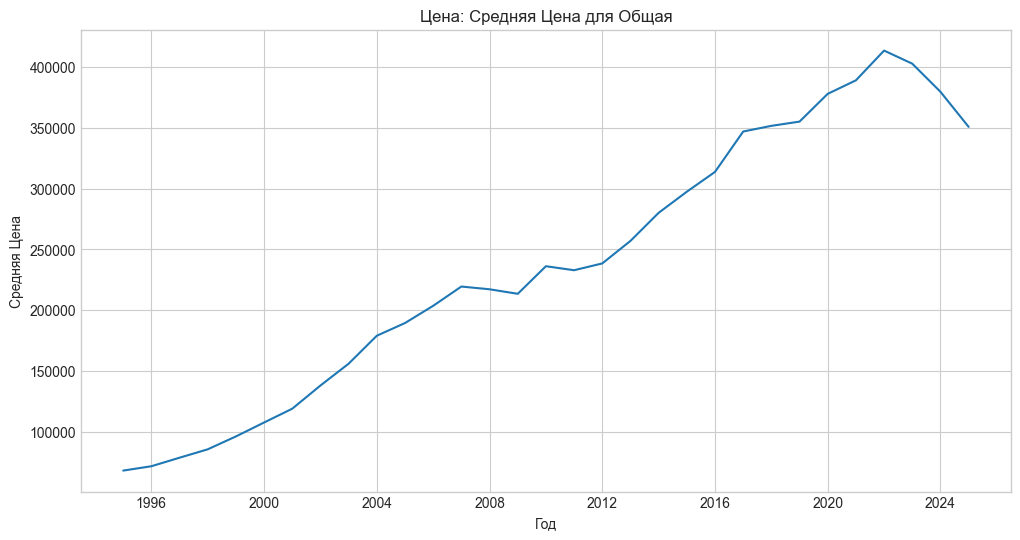

ADF Statistic (d=0): -1.5997198958721275
p-value (d=0): 0.4837341744387741

ADF Statistic (d=1): -3.1587561417258905
p-value (d=1): 0.0224996392788182

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для Общая (на реальных ценах, d=1) ---
Лучшая модель для Общая: ARIMA(1, 1, 2) (AIC=595.50)


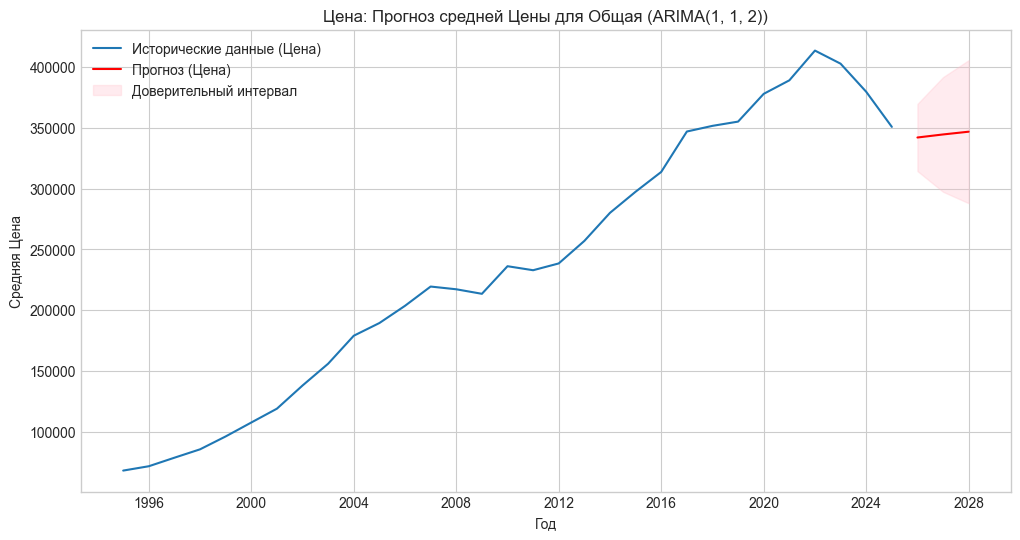


Прогноз цен для Общая на 3 года:
2026-01-01    342035.504693
2027-01-01    344542.871381
2028-01-01    346811.114070
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [30]:
series_total = prepare_timeseries(df_ts)
df_results = plot_arima_forecast_statsmodels(series_total, "Общая", df_results, n_periods=N_FORECAST_YEARS, title_prefix="Цена: ")

## Средняя цена по типу недвижимости (type)

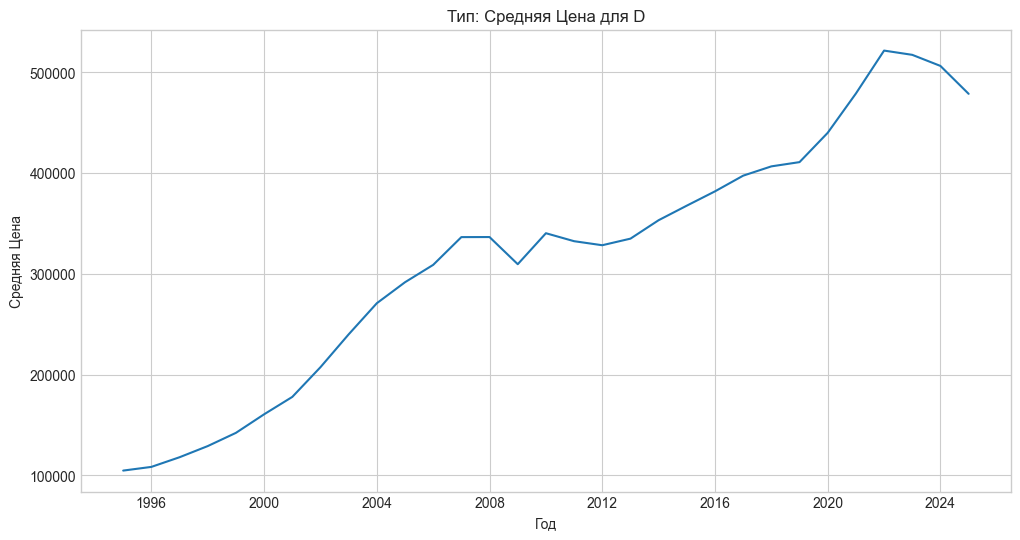

ADF Statistic (d=0): -1.583611780877507
p-value (d=0): 0.49182042352191746

ADF Statistic (d=1): -3.0940346912779395
p-value (d=1): 0.02699780926580508

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для D (на реальных ценах, d=1) ---
Лучшая модель для D: ARIMA(1, 1, 2) (AIC=610.00)


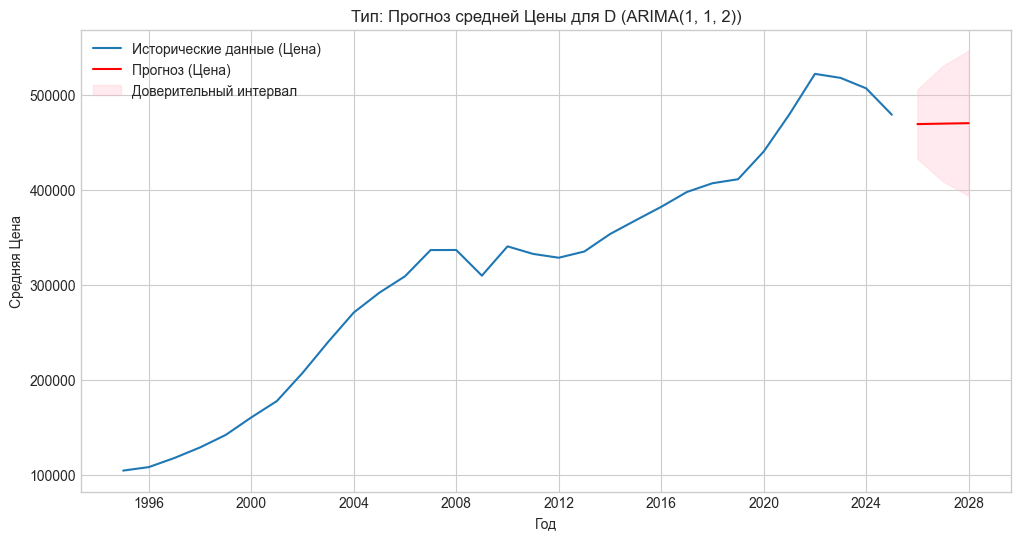


Прогноз цен для D на 3 года:
2026-01-01    468944.932543
2027-01-01    469450.913940
2028-01-01    469902.117034
Freq: YS-JAN, Name: predicted_mean, dtype: float64


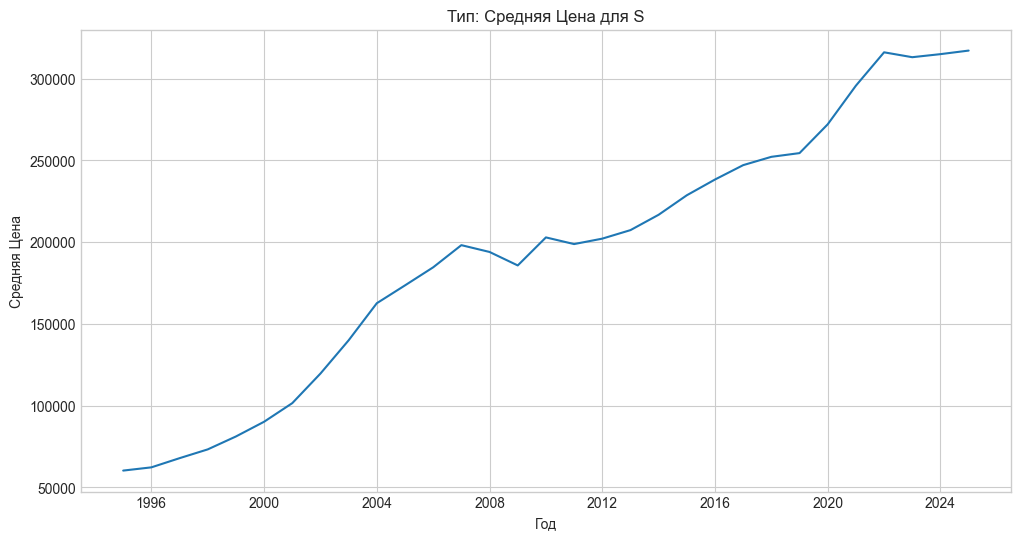

ADF Statistic (d=0): -0.57259675930036
p-value (d=0): 0.8770545965818375

ADF Statistic (d=1): -3.7045766642824747
p-value (d=1): 0.004049237863953324

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для S (на реальных ценах, d=1) ---
Лучшая модель для S: ARIMA(1, 1, 2) (AIC=571.50)


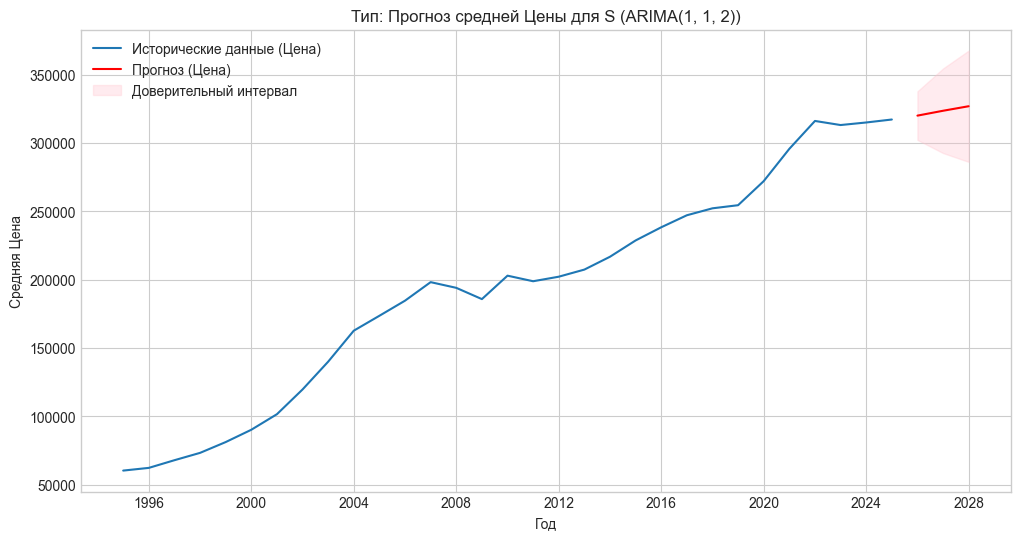


Прогноз цен для S на 3 года:
2026-01-01    319966.774566
2027-01-01    323524.793730
2028-01-01    326840.209537
Freq: YS-JAN, Name: predicted_mean, dtype: float64


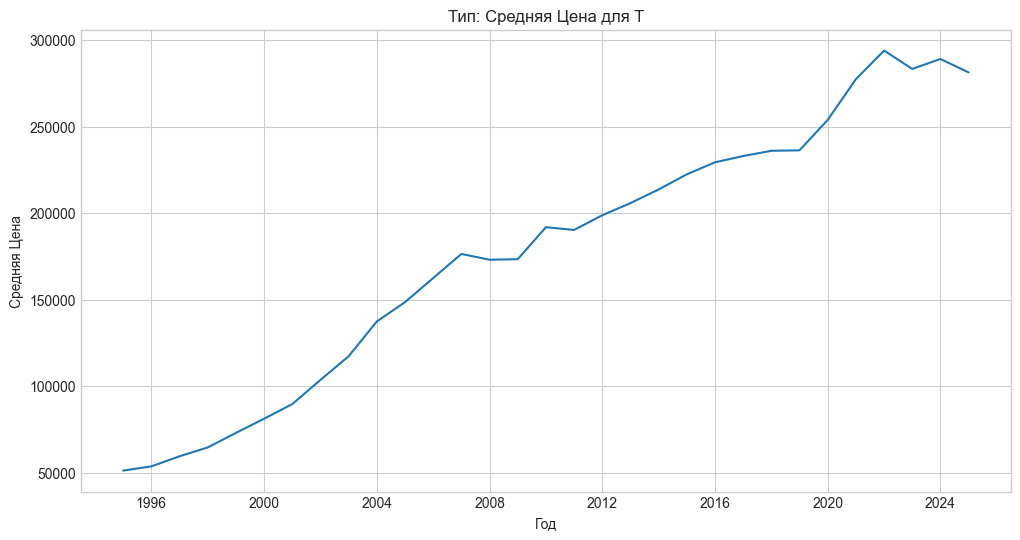

ADF Statistic (d=0): -1.1020489603137822
p-value (d=0): 0.7142541121316424

ADF Statistic (d=1): -4.179678786150472
p-value (d=1): 0.0007130777053128524

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для T (на реальных ценах, d=1) ---
Лучшая модель для T: ARIMA(1, 1, 2) (AIC=571.65)


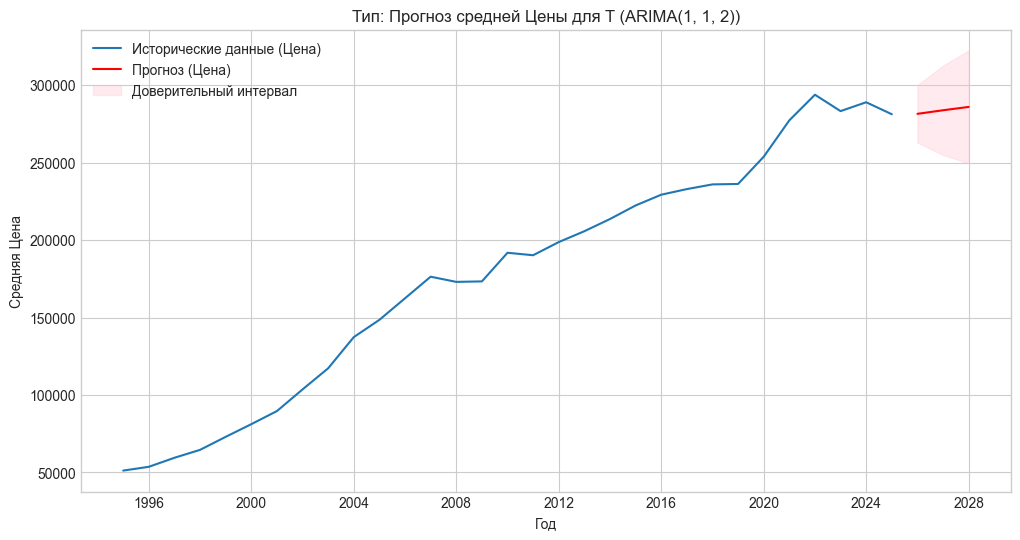


Прогноз цен для T на 3 года:
2026-01-01    281537.540251
2027-01-01    283850.536064
2028-01-01    285999.374679
Freq: YS-JAN, Name: predicted_mean, dtype: float64


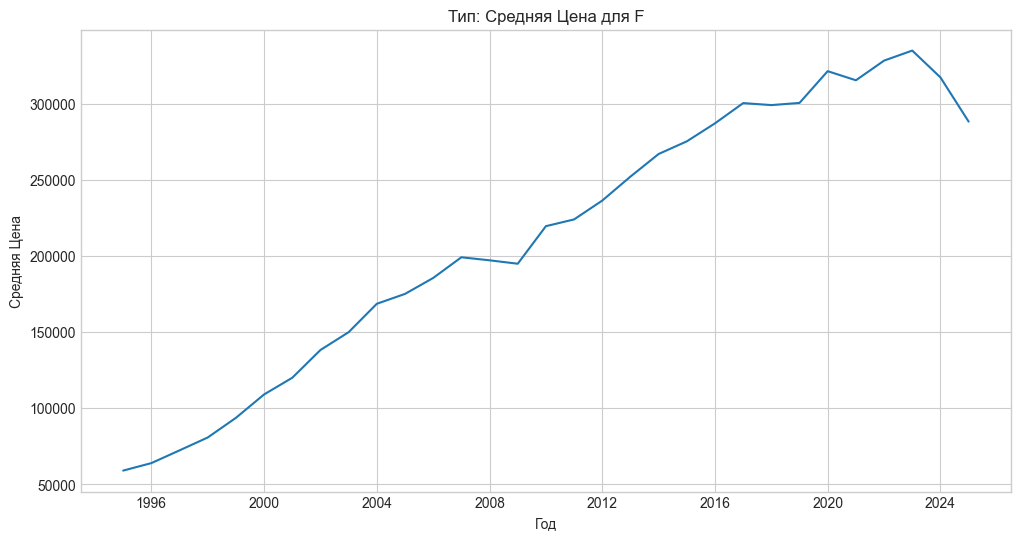

ADF Statistic (d=0): -2.1755655995097194
p-value (d=0): 0.21523293902033358

ADF Statistic (d=1): 1.7905486703813913
p-value (d=1): 0.9983300864895044

ADF Statistic (d=2): -6.01737205825448
p-value (d=2): 1.522313959971671e-07

Ряд стационарен после 2 дифференцирования(ий).
--- Подбор ARIMA для F (на реальных ценах, d=2) ---
Лучшая модель для F: ARIMA(2, 2, 2) (AIC=560.03)


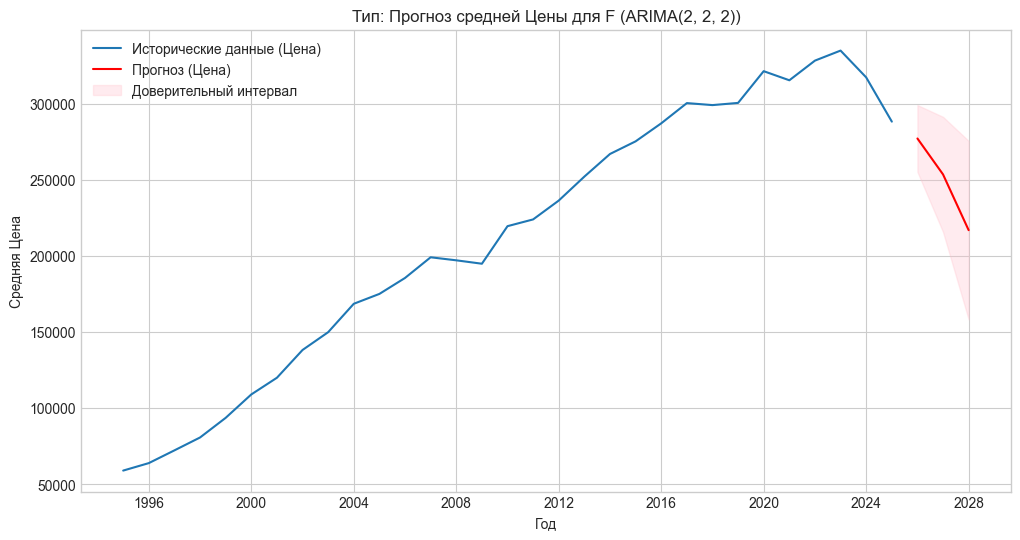


Прогноз цен для F на 3 года:
2026-01-01    277159.943310
2027-01-01    253559.951452
2028-01-01    216957.663283
Freq: YS-JAN, Name: predicted_mean, dtype: float64


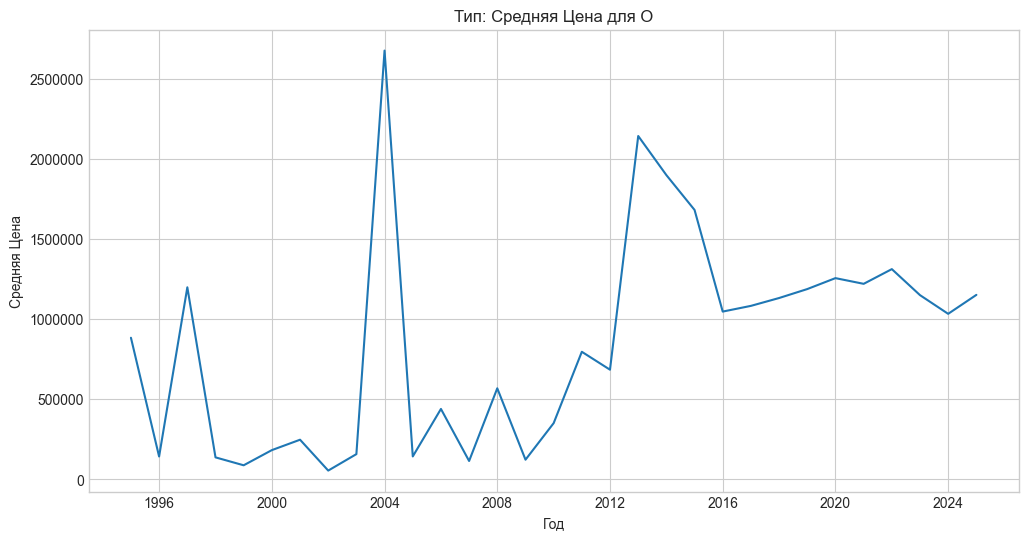

ADF Statistic (d=0): -2.4303480530626485
p-value (d=0): 0.13335343205576944

ADF Statistic (d=1): -2.6809442108834634
p-value (d=1): 0.07739419729146342

ADF Statistic (d=2): -4.120605466204993
p-value (d=2): 0.0008952945149044527

Ряд стационарен после 2 дифференцирования(ий).
--- Подбор ARIMA для O (на реальных ценах, d=2) ---
Лучшая модель для O: ARIMA(0, 2, 2) (AIC=782.45)


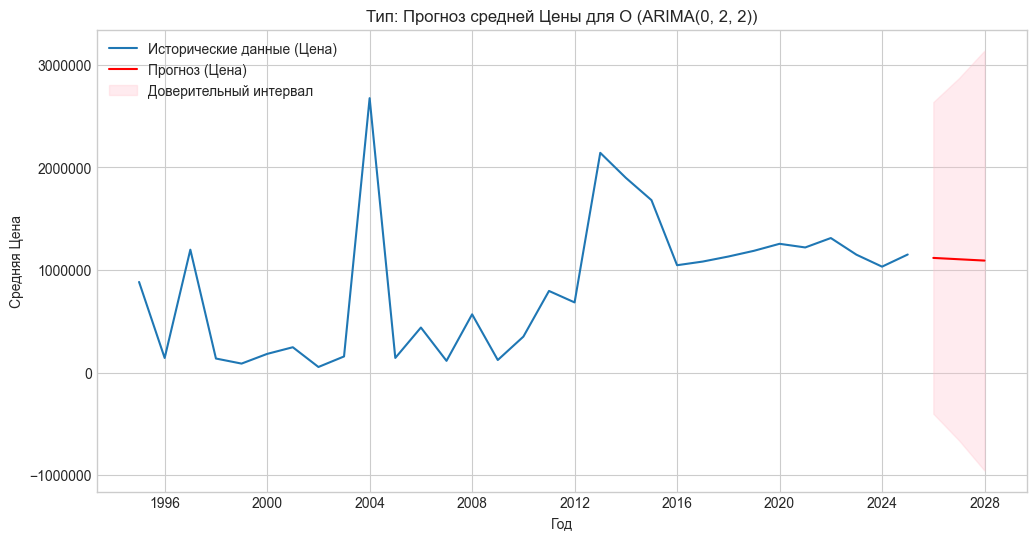


Прогноз цен для O на 3 года:
2026-01-01    1.117850e+06
2027-01-01    1.104854e+06
2028-01-01    1.091858e+06
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [31]:
property_types = df_ts['type'].dropna().unique()
for prop_type in property_types:
    series_type_actual = prepare_timeseries(df_ts, 'type', prop_type)
    df_results = plot_arima_forecast_statsmodels(series_type_actual, f"{prop_type}", df_results, n_periods=N_FORECAST_YEARS, title_prefix="Тип: ")

## Средняя цена по типу новизны дома (old_new)

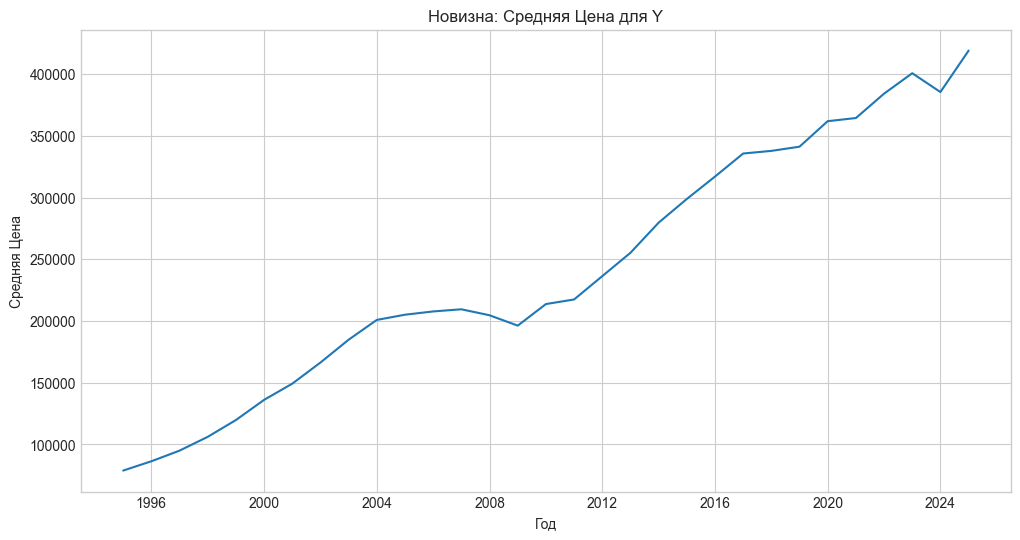

ADF Statistic (d=0): 1.9605957303876116
p-value (d=0): 0.998619508699131

ADF Statistic (d=1): -3.027141018603594
p-value (d=1): 0.03243634016761465

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для Y (на реальных ценах, d=1) ---
Лучшая модель для Y: ARIMA(0, 1, 2) (AIC=587.15)


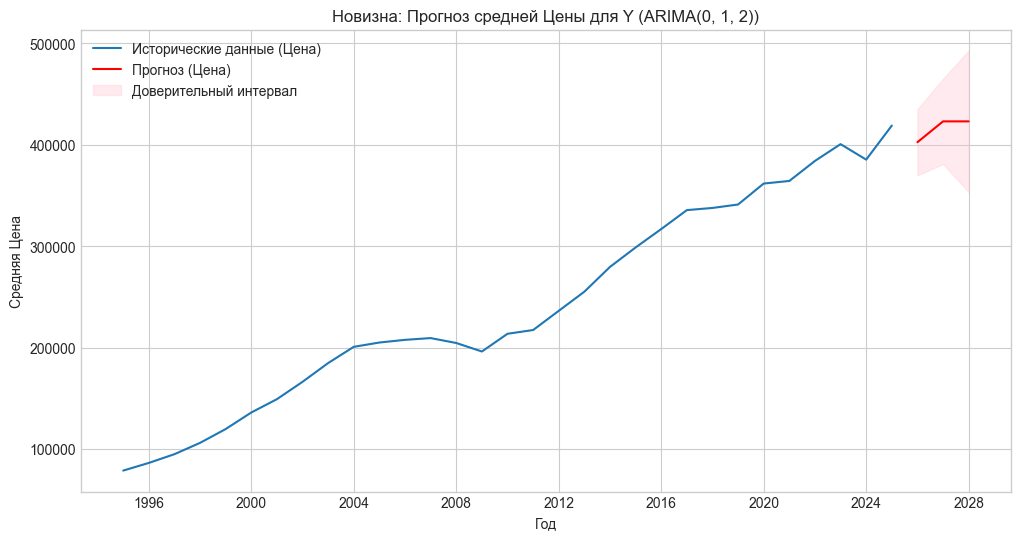


Прогноз цен для Y на 3 года:
2026-01-01    402633.332423
2027-01-01    423178.551382
2028-01-01    423178.551382
Freq: YS-JAN, Name: predicted_mean, dtype: float64


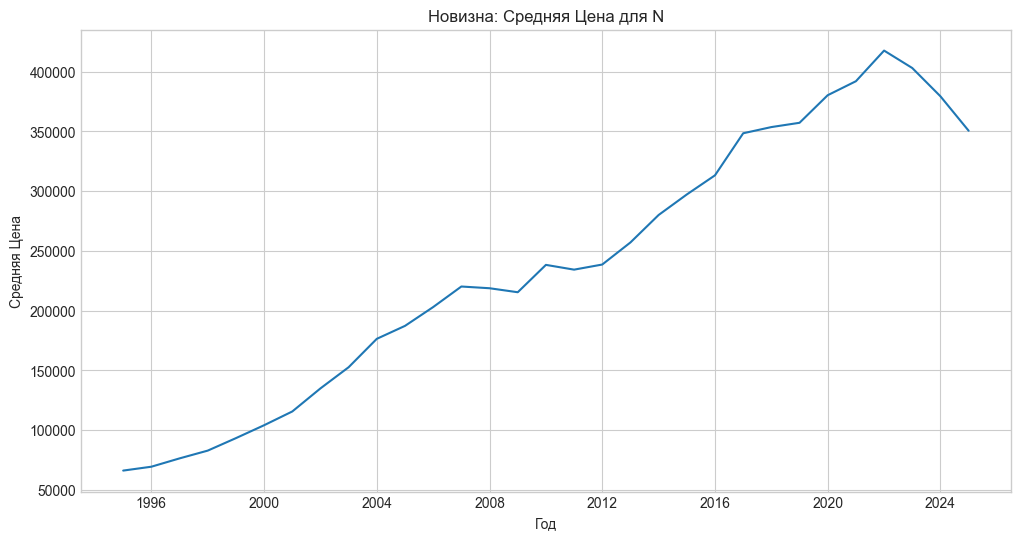

ADF Statistic (d=0): -1.5799200841583902
p-value (d=0): 0.4936719675162628

ADF Statistic (d=1): -3.450431751871157
p-value (d=1): 0.009355192451003502

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для N (на реальных ценах, d=1) ---
Лучшая модель для N: ARIMA(1, 1, 2) (AIC=598.50)


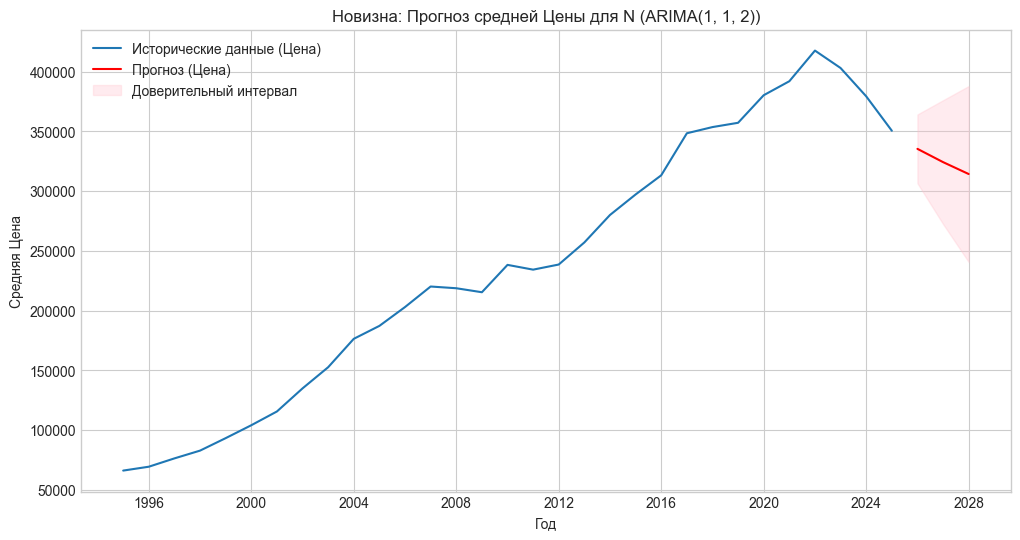


Прогноз цен для N на 3 года:
2026-01-01    335404.486066
2027-01-01    324312.384148
2028-01-01    314361.058103
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [32]:
old_new_types = df_ts['old_new'].dropna().unique()
for on_type in old_new_types:
    series_on_actual = prepare_timeseries(df_ts, 'old_new', on_type)
    df_results = plot_arima_forecast_statsmodels(series_on_actual, f"{on_type}", df_results, n_periods=N_FORECAST_YEARS, title_prefix="Новизна: ")

## Средняя цена по duration

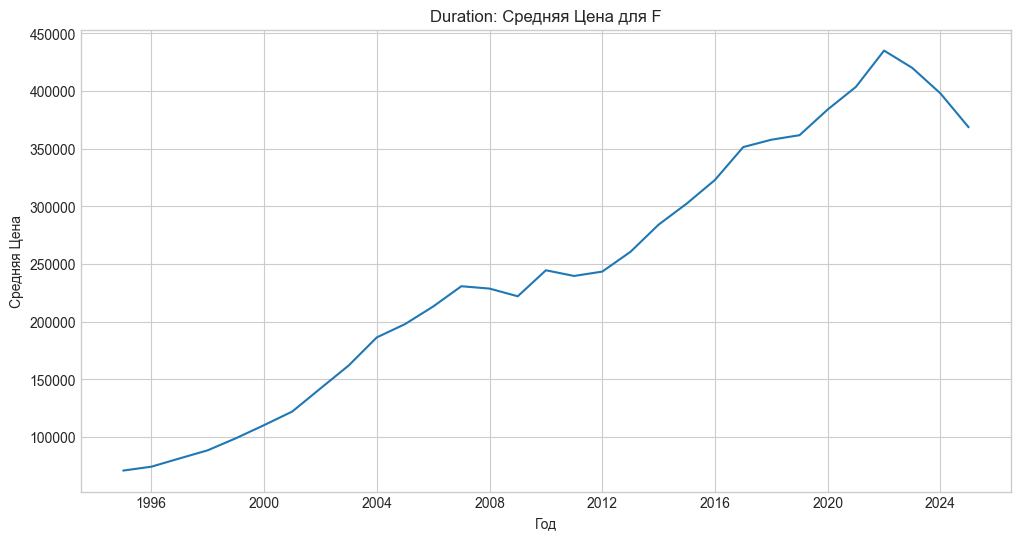

ADF Statistic (d=0): -1.5776363582670792
p-value (d=0): 0.4948169984448407

ADF Statistic (d=1): -3.4753453288901324
p-value (d=1): 0.008643319617430032

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для F (на реальных ценах, d=1) ---
Лучшая модель для F: ARIMA(1, 1, 2) (AIC=598.17)


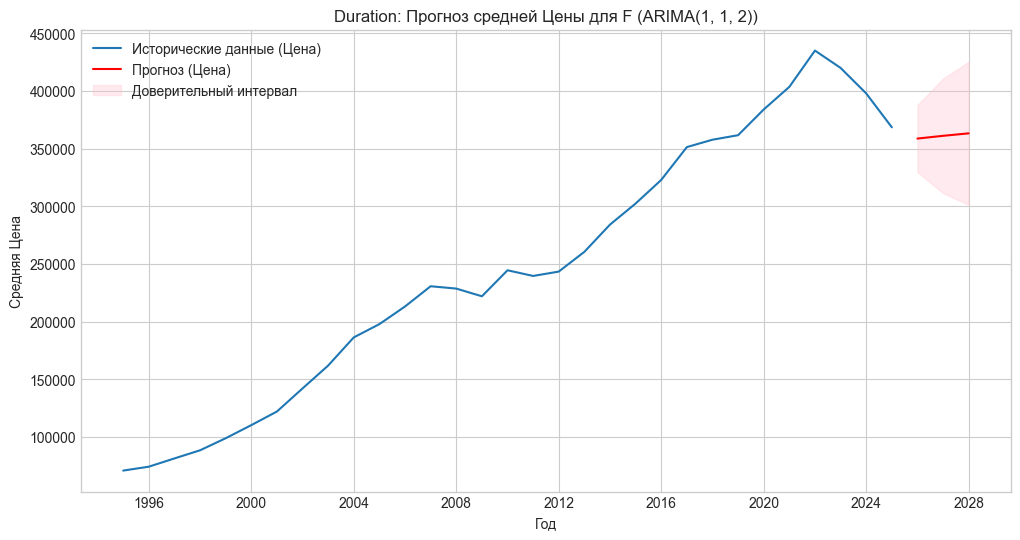


Прогноз цен для F на 3 года:
2026-01-01    358657.410444
2027-01-01    361032.112242
2028-01-01    363182.659976
Freq: YS-JAN, Name: predicted_mean, dtype: float64


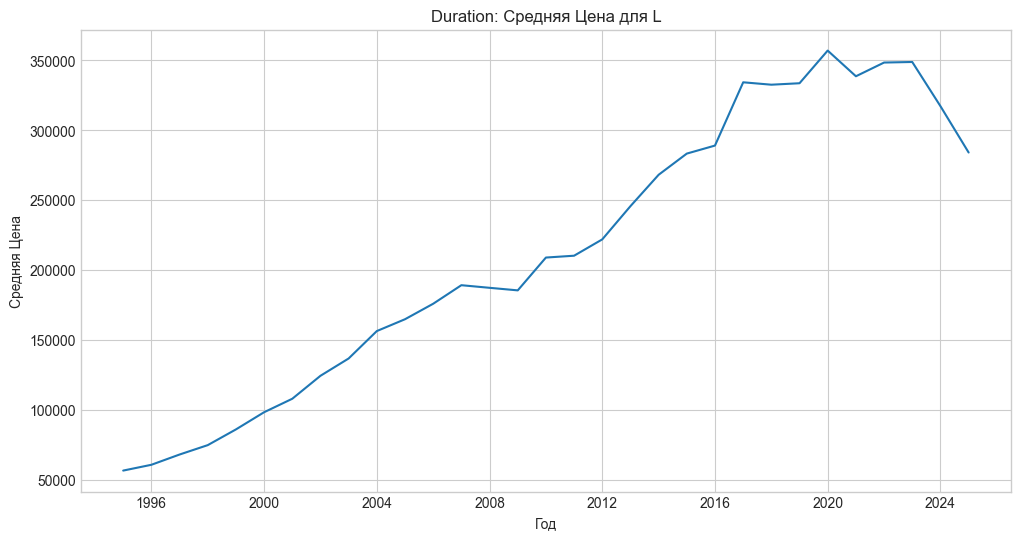

ADF Statistic (d=0): -2.341086235316925
p-value (d=0): 0.15905891722967108

ADF Statistic (d=1): 0.9646381271109319
p-value (d=1): 0.993878466398728

ADF Statistic (d=2): -8.102145089384605
p-value (d=2): 1.2912591866755904e-12

Ряд стационарен после 2 дифференцирования(ий).
--- Подбор ARIMA для L (на реальных ценах, d=2) ---
Лучшая модель для L: ARIMA(2, 2, 2) (AIC=578.36)


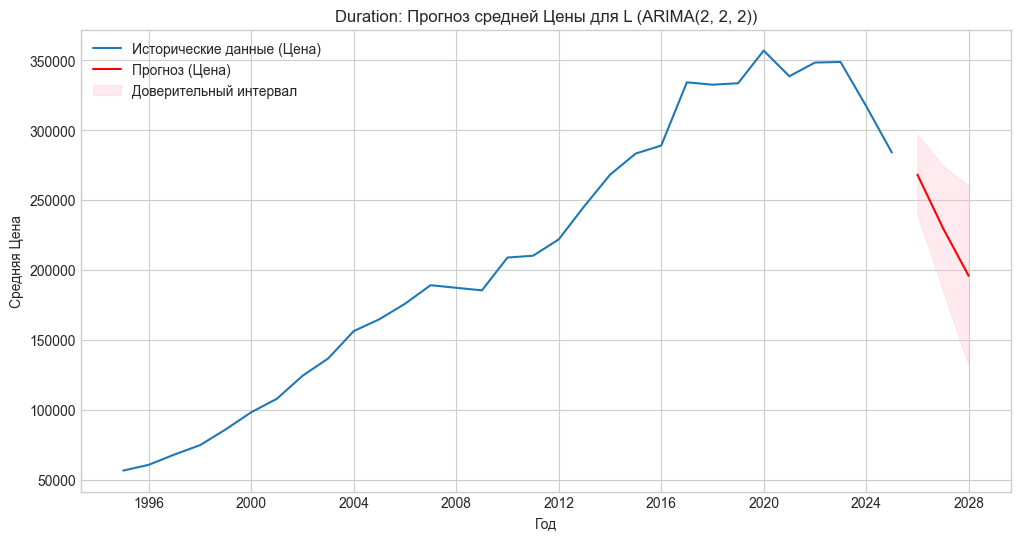


Прогноз цен для L на 3 года:
2026-01-01    268214.558555
2027-01-01    229882.694943
2028-01-01    195856.774445
Freq: YS-JAN, Name: predicted_mean, dtype: float64
Пропуск: Duration: U - недостаточно данных (13 точек).


In [33]:
duration_types = df_ts['duration'].dropna().unique()
for dur_type in duration_types:
    series_dur_actual = prepare_timeseries(df_ts, 'duration', dur_type)
    df_results = plot_arima_forecast_statsmodels(series_dur_actual, f"{dur_type}", df_results, n_periods=N_FORECAST_YEARS, title_prefix="Duration: ")

## Средняя цена по town_city (Топ-N городов)

Анализируем для городов: ['LONDON', 'MANCHESTER', 'BRISTOL', 'BIRMINGHAM', 'NOTTINGHAM']


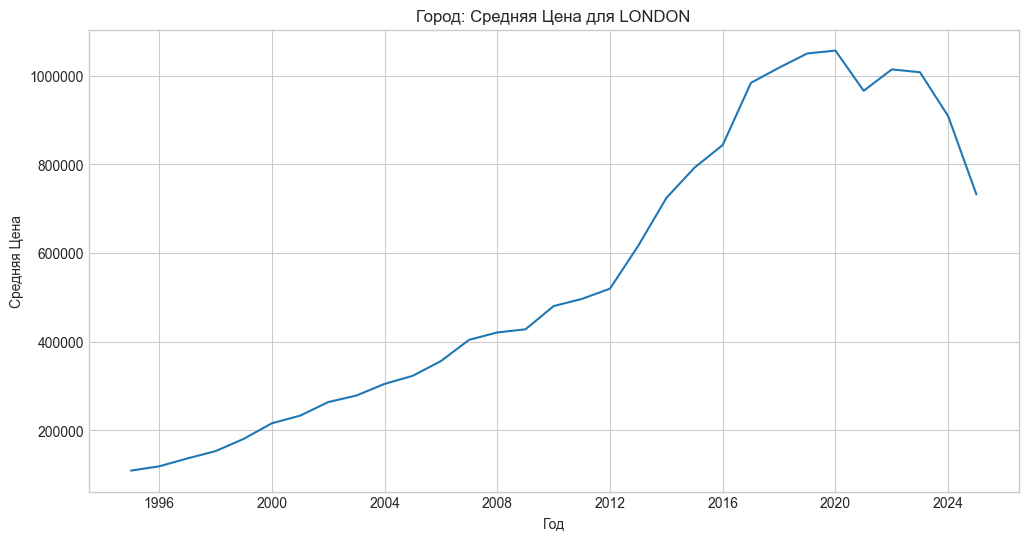

ADF Statistic (d=0): -0.7689773808989377
p-value (d=0): 0.8280653414254201

ADF Statistic (d=1): -1.4787197830563
p-value (d=1): 0.5440108696825122

ADF Statistic (d=2): -2.1230380462952967
p-value (d=2): 0.23535235043499403

Ряд НЕ стационарен даже после 2 дифференцирования(ий). Используем d=2.
--- Подбор ARIMA для LONDON (на реальных ценах, d=2) ---
Лучшая модель для LONDON: ARIMA(2, 2, 2) (AIC=640.63)


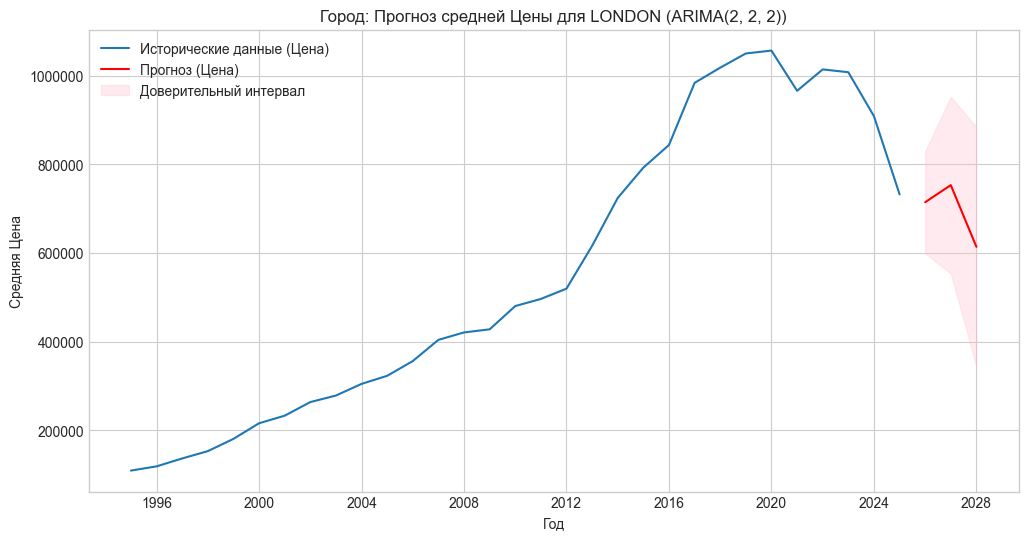


Прогноз цен для LONDON на 3 года:
2026-01-01    714657.554327
2027-01-01    753154.577052
2028-01-01    613987.132930
Freq: YS-JAN, Name: predicted_mean, dtype: float64


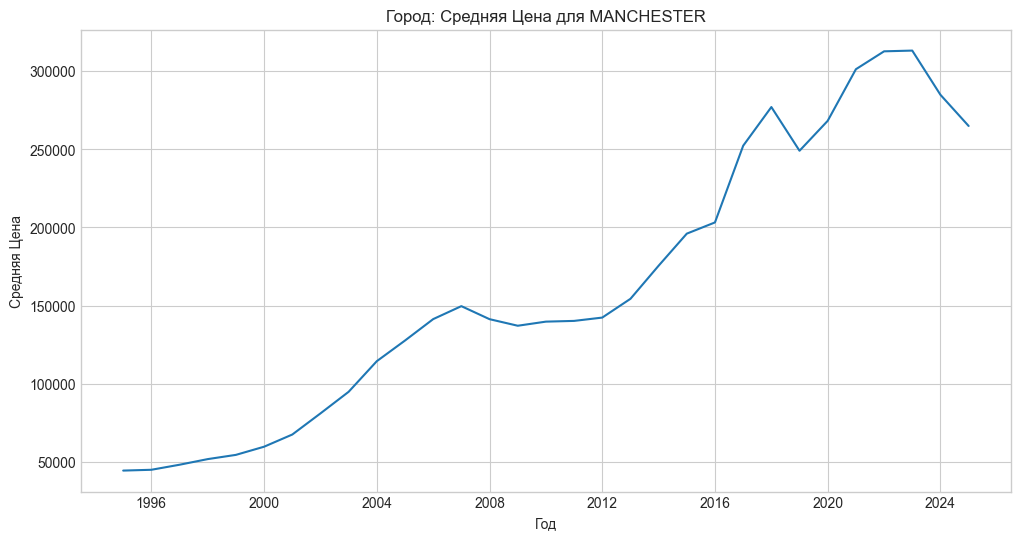

ADF Statistic (d=0): 1.9473966524944102
p-value (d=0): 0.9986005723963887

ADF Statistic (d=1): -1.2694297142900706
p-value (d=1): 0.6430396634783497

ADF Statistic (d=2): -2.759150627152815
p-value (d=2): 0.06434987211829503

Ряд НЕ стационарен даже после 2 дифференцирования(ий). Используем d=2.
--- Подбор ARIMA для MANCHESTER (на реальных ценах, d=2) ---
Лучшая модель для MANCHESTER: ARIMA(0, 2, 2) (AIC=580.39)


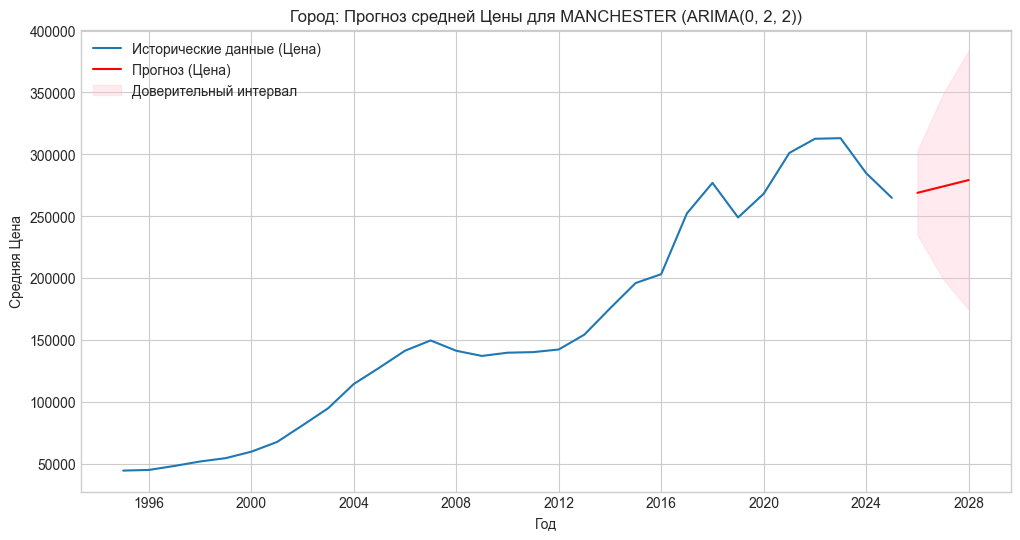


Прогноз цен для MANCHESTER на 3 года:
2026-01-01    268935.710230
2027-01-01    274093.413147
2028-01-01    279251.116064
Freq: YS-JAN, Name: predicted_mean, dtype: float64


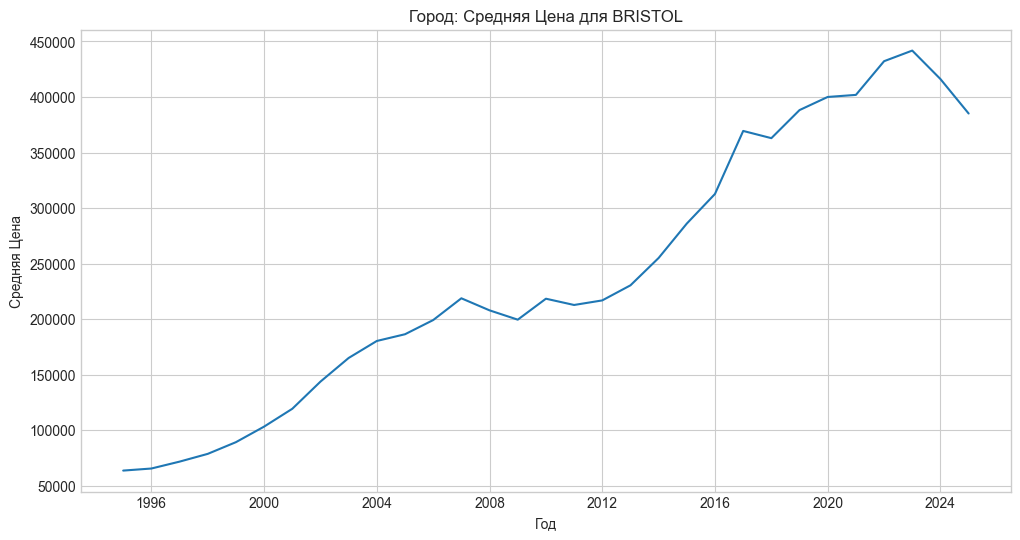

ADF Statistic (d=0): -0.8269216874648415
p-value (d=0): 0.8110858481418877

ADF Statistic (d=1): -3.4168729865138676
p-value (d=1): 0.010396946109046703

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для BRISTOL (на реальных ценах, d=1) ---
Лучшая модель для BRISTOL: ARIMA(1, 1, 2) (AIC=612.85)


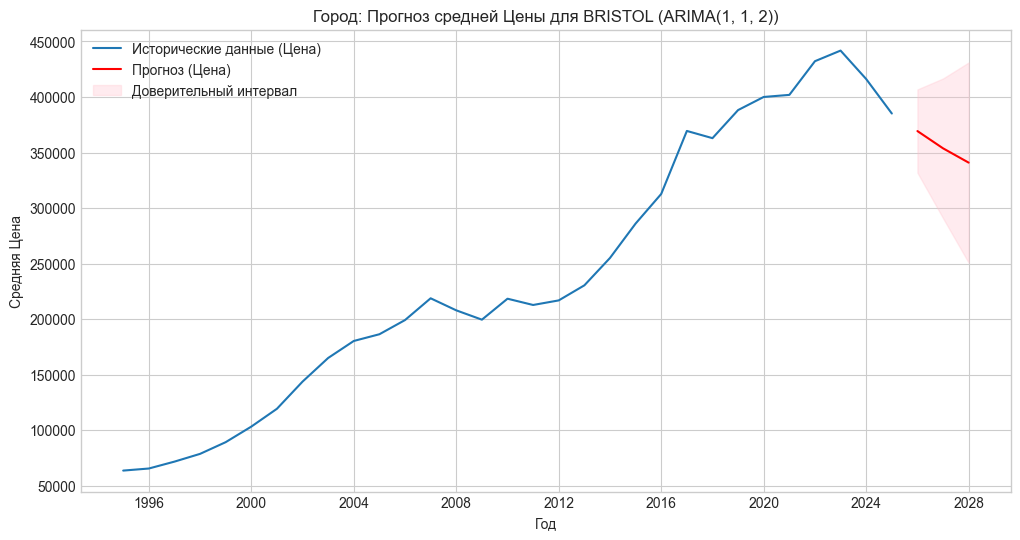


Прогноз цен для BRISTOL на 3 года:
2026-01-01    369300.808215
2027-01-01    353757.886483
2028-01-01    340886.066992
Freq: YS-JAN, Name: predicted_mean, dtype: float64


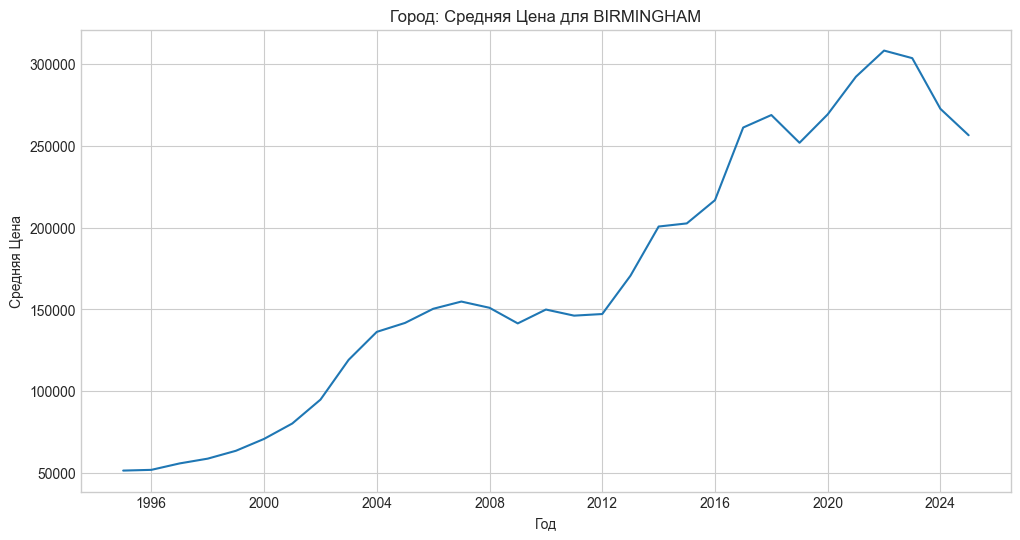

ADF Statistic (d=0): 1.055537465994848
p-value (d=0): 0.9948187048064635

ADF Statistic (d=1): -3.1783836087903072
p-value (d=1): 0.02127051493416662

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для BIRMINGHAM (на реальных ценах, d=1) ---
Лучшая модель для BIRMINGHAM: ARIMA(1, 1, 2) (AIC=592.98)


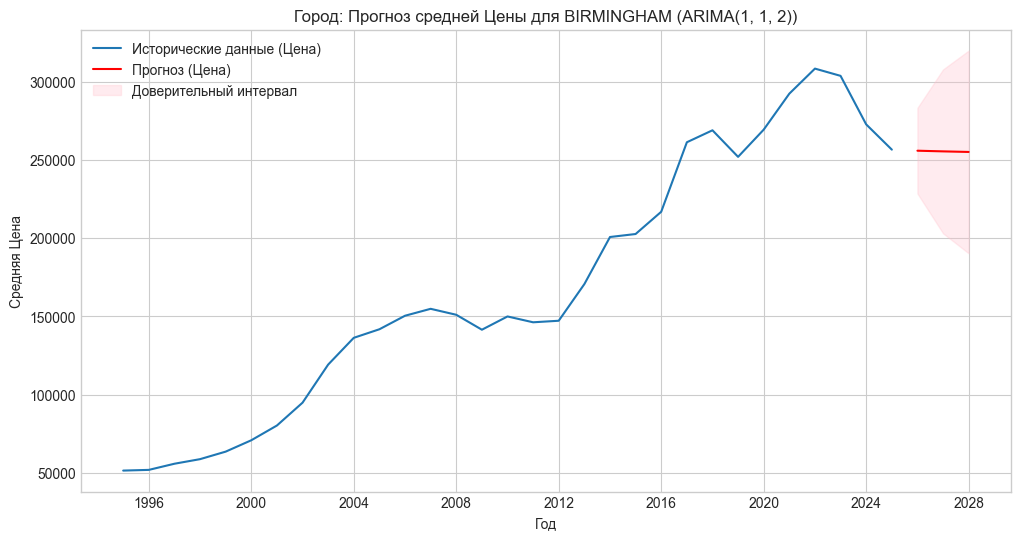


Прогноз цен для BIRMINGHAM на 3 года:
2026-01-01    255878.580749
2027-01-01    255453.492702
2028-01-01    255085.824043
Freq: YS-JAN, Name: predicted_mean, dtype: float64


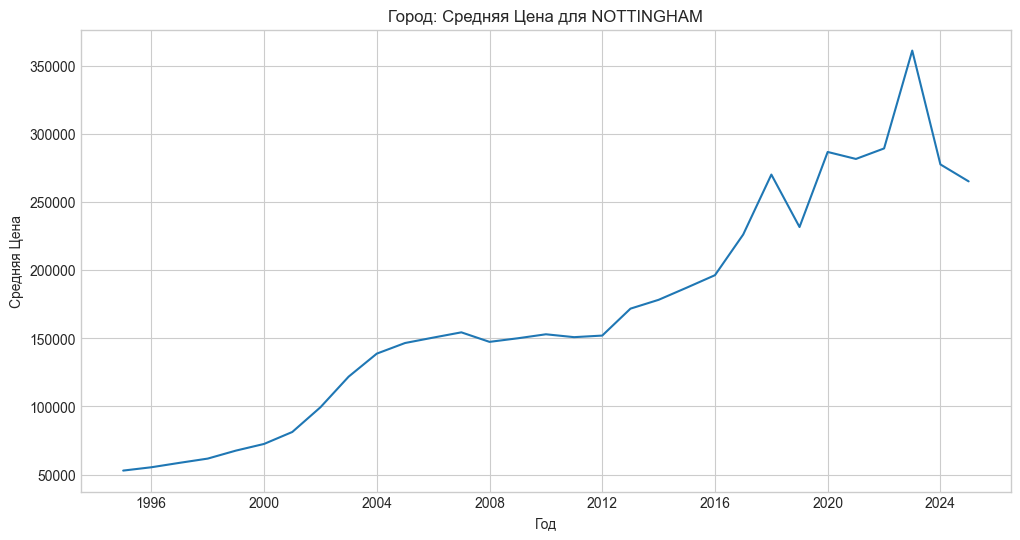

ADF Statistic (d=0): 0.5238341088028949
p-value (d=0): 0.9855797919124906

ADF Statistic (d=1): -3.027449454545544
p-value (d=1): 0.03240927278296355

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для NOTTINGHAM (на реальных ценах, d=1) ---
Лучшая модель для NOTTINGHAM: ARIMA(2, 1, 2) (AIC=629.96)


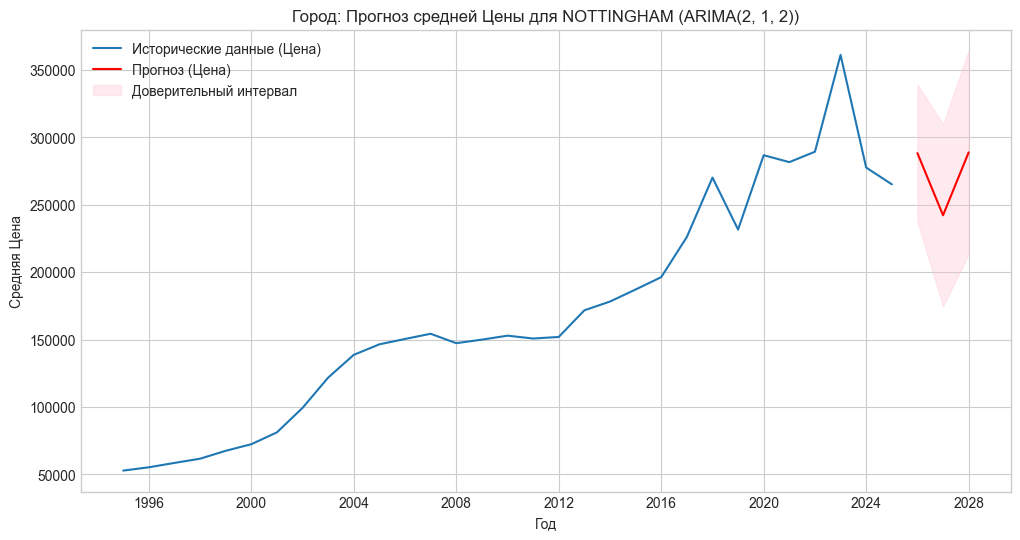


Прогноз цен для NOTTINGHAM на 3 года:
2026-01-01    288255.184733
2027-01-01    242211.494676
2028-01-01    288812.038193
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [34]:
top_n_cities = 5
city_counts_per_year = df_ts.groupby(['town_city', 'year']).size().reset_index(name='count')
cities_with_enough_years = city_counts_per_year.groupby('town_city')['year'].nunique()
# Увеличим порог лет для городов, так как цены могут сильно варьироваться
cities_to_analyze_list = cities_with_enough_years[cities_with_enough_years >= 15].index.tolist() 

if cities_to_analyze_list:
    city_total_counts = df_ts[df_ts['town_city'].isin(cities_to_analyze_list)]['town_city'].value_counts()
    selected_cities = city_total_counts.nlargest(top_n_cities).index.tolist()
    print(f"Анализируем для городов: {selected_cities}")
    for city in selected_cities:
        series_city_actual = prepare_timeseries(df_ts, 'town_city', city)
        df_results = plot_arima_forecast_statsmodels(series_city_actual, f"{city}", df_results, n_periods=N_FORECAST_YEARS, title_prefix="Город: ")
else:
    print("Не найдено городов с достаточным количеством данных (>= 15 лет) для анализа.")


## Средняя цена по ppd_type

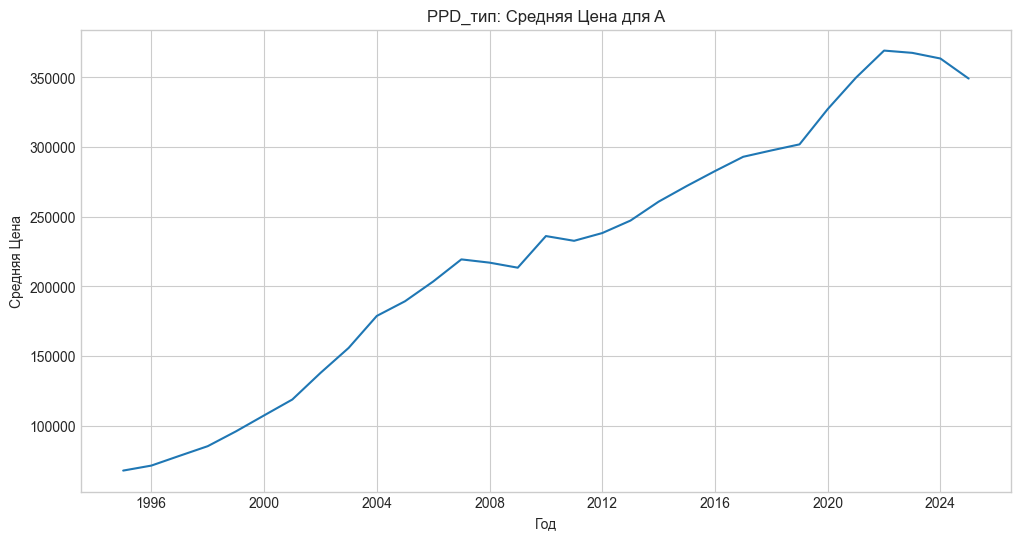

ADF Statistic (d=0): -1.1916186145905652
p-value (d=0): 0.6771907403109289

ADF Statistic (d=1): -3.120114117163249
p-value (d=1): 0.025100022131511874

Ряд стационарен после 1 дифференцирования(ий).
--- Подбор ARIMA для A (на реальных ценах, d=1) ---
Лучшая модель для A: ARIMA(1, 1, 2) (AIC=578.39)


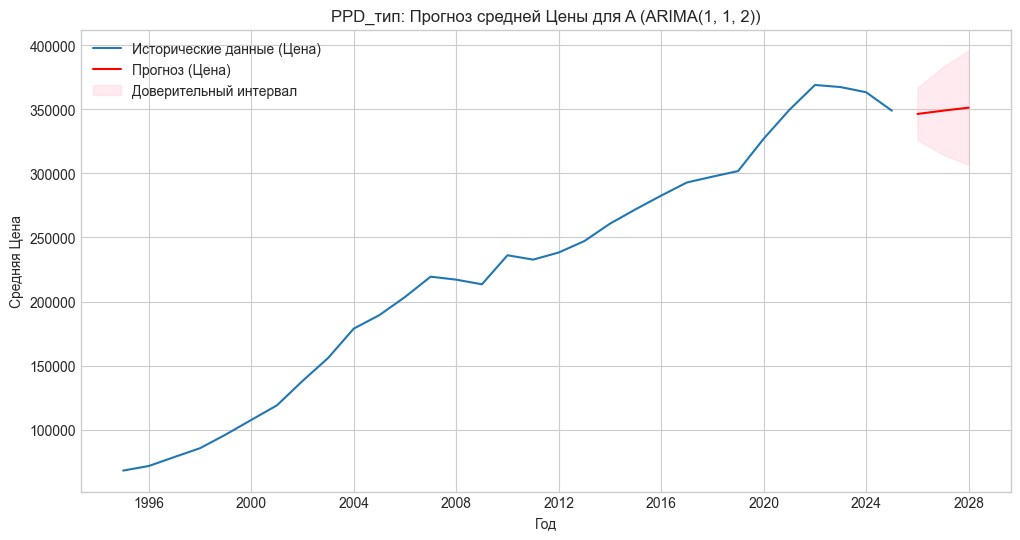


Прогноз цен для A на 3 года:
2026-01-01    346495.004958
2027-01-01    349046.852939
2028-01-01    351404.582227
Freq: YS-JAN, Name: predicted_mean, dtype: float64


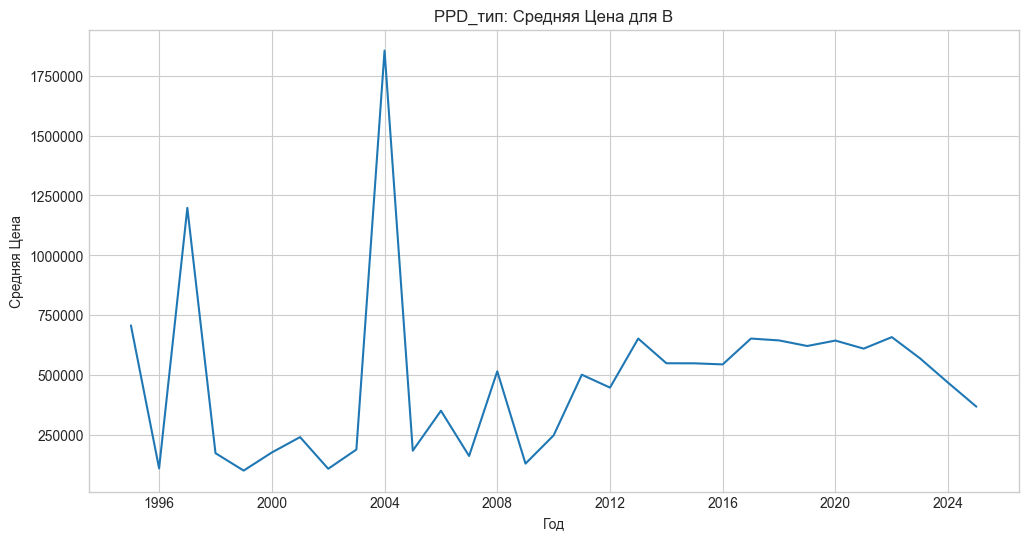

ADF Statistic (d=0): -6.209474100113609
p-value (d=0): 5.552853225407147e-08

Ряд стационарен после 0 дифференцирования(ий).
--- Подбор ARIMA для B (на реальных ценах, d=0) ---
Лучшая модель для B: ARIMA(0, 0, 2) (AIC=799.36)


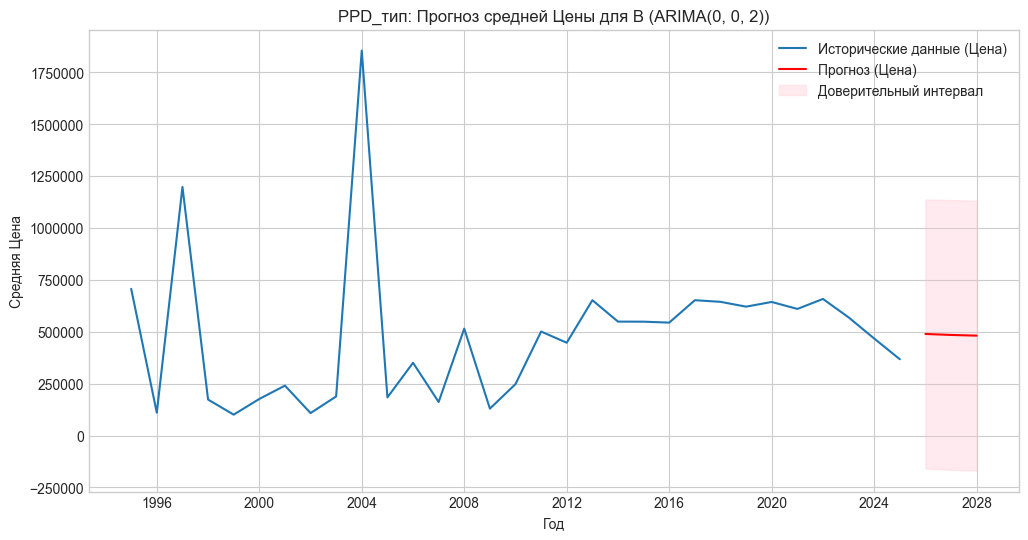


Прогноз цен для B на 3 года:
2026-01-01    489724.215453
2027-01-01    484951.664158
2028-01-01    481623.302050
Freq: YS-JAN, Name: predicted_mean, dtype: float64


In [35]:
ppd_types = df_ts['ppd_type'].dropna().unique()
for p_type in ppd_types:
    series_ppd_actual = prepare_timeseries(df_ts, 'ppd_type', p_type)
    df_results = plot_arima_forecast_statsmodels(series_ppd_actual, f"{p_type}", df_results, n_periods=N_FORECAST_YEARS, title_prefix="PPD_тип: ")

# Save CSV

In [36]:
df_results_to_save = df_results.copy()
# Преобразуем индекс (DatetimeIndex) в колонку 'year' (только год)
df_results_to_save.index.name = 'datetime_index_col' # Временно даем имя, чтобы reset_index сработал
df_results_to_save.reset_index(inplace=True)
df_results_to_save['year'] = df_results_to_save['datetime_index_col'].dt.year
df_results_to_save.drop(columns=['datetime_index_col'], inplace=True)
# Делаем 'year' первой колонкой
cols = ['year'] + [col for col in df_results_to_save.columns if col != 'year']
df_results_to_save = df_results_to_save[cols]


output_csv_path = 'arima_forecast_results_actual_price.csv'
try:
    df_results_to_save.to_csv(output_csv_path, index=False, float_format='%.0f') # Цены без десятичных знаков
    print(f"\nРезультаты сохранены в файл: {output_csv_path}")
except Exception as e:
    print(f"\nОшибка при сохранении CSV: {e}")
    print("Вывод df_results для отладки:")
    print(df_results_to_save.head())


Результаты сохранены в файл: arima_forecast_results_actual_price.csv


## 